Gera o dataset sintético: preços, retornos e o alvo (retorno futuro de 5 dias), e salva em CSV.

In [1]:
import pandas as pd
import numpy as np
#Matplotlib: Possui uma série de funções e comandos para exibição de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Reprodutibilidade
rng = np.random.default_rng(42)

# Parâmetros
n_days = 1500
n_assets = 50
dates = pd.bdate_range("2020-01-01", periods=n_days)
tickers = [f"ASSET_{i:02d}" for i in range(1, n_assets + 1)]

# Fatores de mercado/setor
market = rng.normal(0, 0.008, n_days)
sector = rng.normal(0, 0.004, (n_days, 5))

rows = []

for j, ticker in enumerate(tickers):
    sector_id = j % 5
    beta = rng.uniform(0.7, 1.3)
    idio_vol = rng.uniform(0.006, 0.015)
    
    # Componente de retorno com leve mean reversion
    mr_strength = rng.uniform(0.03, 0.10)
    noise = rng.normal(0, idio_vol, n_days)

    # Nível latente que reverte à média (processo tipo Ornstein-Uhlenbeck)
    idio_level = np.zeros(n_days)
    for t in range(1, n_days):
        idio_level[t] = (1 - mr_strength) * idio_level[t-1] + noise[t]

    # O retorno idiossincrático é a VARIAÇÃO do nível, não o nível em si
    # (o nível decai devagar; somá-lo direto todo dia infla o retorno artificialmente)
    idio_return = np.diff(idio_level, prepend=0.0)

    log_return = (
        0.00015
        + beta * market
        + sector[:, sector_id]
        + idio_return
    )
    
    # Preço a partir do log return
    price = 100 * np.exp(np.cumsum(log_return))
    
    # Volume correlacionado com volatilidade
    volume = rng.lognormal(mean=13, sigma=0.35, size=n_days)
    
    for t in range(n_days):
        rows.append([
            dates[t], ticker, price[t], log_return[t], volume[t], sector_id
        ])

df = pd.DataFrame(
    rows,
    columns=["date", "ticker", "close", "log_return", "volume", "sector"]
)

# Features calculáveis sem olhar o futuro
df["return_1d"] = df.groupby("ticker")["close"].pct_change(1)
df["return_5d"] = df.groupby("ticker")["close"].pct_change(5)
df["return_20d"] = df.groupby("ticker")["close"].pct_change(20)
df["volatility_20d"] = (
    df.groupby("ticker")["log_return"]
      .transform(lambda x: x.rolling(20).std())
)

# Target: log return futuro de 5 dias
df["target_log_return_5d"] = (
    df.groupby("ticker")["close"]
      .transform(lambda x: np.log(x.shift(-5) / x))
)

# Z-score cross-sectional do retorno de 5 dias
df["cs_zscore_5d"] = (
    df.groupby("date")["return_5d"]
      .transform(lambda x: (x - x.mean()) / x.std())
)

# Remove linhas sem janela completa
df = df.dropna().reset_index(drop=True)

path = "dataset_stat_arb_ml.csv"  # caminho relativo — roda em qualquer máquina
df.to_csv(path, index=False)
print(f"Dataset criado: {path}")
print(f"Linhas: {len(df):,}")

print(f"Dataset criado: {path}")
print(f"Linhas: {len(df):,}")
print(f"Ativos: {df['ticker'].nunique()}")
print(f"Período: {df['date'].min().date()} a {df['date'].max().date()}")
print("\nColunas:")
print(df.columns.tolist())
print("\nPrimeiras linhas:")
print(df.head())


Dataset criado: dataset_stat_arb_ml.csv
Linhas: 73,750
Dataset criado: dataset_stat_arb_ml.csv
Linhas: 73,750
Ativos: 50
Período: 2020-01-29 a 2025-09-23

Colunas:
['date', 'ticker', 'close', 'log_return', 'volume', 'sector', 'return_1d', 'return_5d', 'return_20d', 'volatility_20d', 'target_log_return_5d', 'cs_zscore_5d']

Primeiras linhas:
        date    ticker       close  log_return         volume  sector  \
0 2020-01-29  ASSET_01   98.970264    0.001345  304608.690484       0   
1 2020-01-30  ASSET_01   99.844445    0.008794  519383.819093       0   
2 2020-01-31  ASSET_01   99.910379    0.000660  559354.513374       0   
3 2020-02-03  ASSET_01  100.354199    0.004432  365247.960204       0   
4 2020-02-04  ASSET_01   99.763104   -0.005908  267070.367391       0   

   return_1d  return_5d  return_20d  volatility_20d  target_log_return_5d  \
0   0.001346   0.013112   -0.010088        0.011943              0.012749   
1   0.008833   0.018826   -0.005267        0.012087             

# Este projeto desenvolve uma estratégia de Statistical Arbitrage utilizando Machine Learning para prever o log return futuro de ativos e, a partir dessas previsões, construir um ranking diário que define posições Long/Short.

As primeiras linhas do dataset.

In [2]:
df.head()

,date,ticker,close,log_return,volume,sector,return_1d,return_5d,return_20d,volatility_20d,target_log_return_5d,cs_zscore_5d
0,2020-01-29,ASSET_01,98.970264,0.001345,304608.690484,0,0.001346,0.013112,-0.010088,0.011943,0.012749,0.680741
1,2020-01-30,ASSET_01,99.844445,0.008794,519383.819093,0,0.008833,0.018826,-0.005267,0.012087,0.006820,1.193829
2,2020-01-31,ASSET_01,99.910379,0.000660,559354.513374,0,0.000660,0.029088,-0.028123,0.010676,0.012610,0.831813
3,2020-02-03,ASSET_01,100.354199,0.004432,365247.960204,0,0.004442,0.032231,-0.032960,0.010465,0.021172,0.967967
4,2020-02-04,ASSET_01,99.763104,-0.005908,267070.367391,0,-0.005890,0.009368,-0.016833,0.009329,0.038954,0.180687


As últimas linhas do dataset.

In [3]:
df.tail()

,date,ticker,close,log_return,volume,sector,return_1d,return_5d,return_20d,volatility_20d,target_log_return_5d,cs_zscore_5d
73745,2025-09-17,ASSET_50,104.347676,-0.018131,860284.029386,4,-0.017968,-0.032705,-0.081004,0.017685,-0.023908,-1.022786
73746,2025-09-18,ASSET_50,103.410751,-0.009019,545002.318155,4,-0.008979,-0.058543,-0.088243,0.017700,-0.004508,-1.654697
73747,2025-09-19,ASSET_50,105.933313,0.024101,473426.496760,4,0.024394,-0.008877,-0.068746,0.018776,-0.050127,0.101025
73748,2025-09-22,ASSET_50,102.982572,-0.028250,187340.096694,4,-0.027855,-0.037435,-0.066712,0.018617,-0.022619,-0.723193
73749,2025-09-23,ASSET_50,102.318995,-0.006464,352626.245902,4,-0.006444,-0.037060,-0.088743,0.017962,-0.022946,-0.457807


Os tipos de dados e a contagem de valores não nulos de cada coluna.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73750 entries, 0 to 73749
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   date                  73750 non-null  datetime64[ns]
 1   ticker                73750 non-null  object        
 2   close                 73750 non-null  float64       
 3   log_return            73750 non-null  float64       
 4   volume                73750 non-null  float64       
 5   sector                73750 non-null  int64         
 6   return_1d             73750 non-null  float64       
 7   return_5d             73750 non-null  float64       
 8   return_20d            73750 non-null  float64       
 9   volatility_20d        73750 non-null  float64       
 10  target_log_return_5d  73750 non-null  float64       
 11  cs_zscore_5d          73750 non-null  float64       
dtypes: datetime64[ns](1), float64(9), int64(1), object(1)
memory usage: 6.8+ M

Estatísticas descritivas (média, desvio padrão, quartis) das colunas numéricas.

In [5]:
df.describe()

,date,close,log_return,volume,sector,return_1d,return_5d,return_20d,volatility_20d,target_log_return_5d,cs_zscore_5d
count,73750,73750.000000,73750.000000,7.375000e+04,73750.000000,73750.000000,73750.000000,73750.000000,73750.000000,73750.000000,7.375000e+04
mean,2022-11-25 19:12:00,93.290510,0.000002,4.707642e+05,2.000000,0.000101,0.000528,0.001642,0.013777,-0.000031,5.250790e-18
min,2020-01-29 00:00:00,60.978250,-0.076917,9.971254e+04,0.000000,-0.074034,-0.145722,-0.202930,0.004278,-0.157498,-4.366965e+00
25%,2021-06-28 00:00:00,86.077989,-0.009093,3.487882e+05,1.000000,-0.009052,-0.019820,-0.035335,0.011517,-0.020139,-6.478031e-01
50%,2022-11-25 00:00:00,93.190681,0.000093,4.417984e+05,2.000000,0.000093,0.000547,0.000050,0.013472,0.000451,-9.152907e-03
75%,2024-04-25 00:00:00,100.279358,0.009114,5.608890e+05,3.000000,0.009155,0.020632,0.035926,0.015748,0.020352,6.405567e-01
max,2025-09-23 00:00:00,134.917446,0.082378,2.201773e+06,4.000000,0.085867,0.170339,0.347017,0.028557,0.157294,4.723397e+00
std,NaN,10.473457,0.014029,1.711919e+05,1.414223,0.014031,0.030875,0.054015,0.003119,0.030910,9.899562e-01


O número de linhas e colunas do dataset.

In [6]:
df.shape

(73750, 12)

Os nomes de todas as colunas.

In [7]:
df.columns

Index(['date', 'ticker', 'close', 'log_return', 'volume', 'sector',
       'return_1d', 'return_5d', 'return_20d', 'volatility_20d',
       'target_log_return_5d', 'cs_zscore_5d'],
      dtype='object')

O percentual de valores ausentes em cada coluna.

In [8]:
df.isnull().sum() * 100 / len(df)

date                    0.0
ticker                  0.0
close                   0.0
log_return              0.0
volume                  0.0
sector                  0.0
return_1d               0.0
return_5d               0.0
return_20d              0.0
volatility_20d          0.0
target_log_return_5d    0.0
cs_zscore_5d            0.0
dtype: float64

# Profile Report

Utilizando o Profile Report para reazilar a exploração inicial dos dados

Gera um relatório automático de exploração dos dados (desativado aqui; precisa da lib `ydata_profiling` instalada).

In [9]:
# from ydata_profiling import ProfileReport

# profile = ProfileReport(df)

# profile.to_file("mean_reversion.html")

Verifica se existem linhas duplicadas no dataset.

In [10]:
df[df.duplicated()]

,date,ticker,close,log_return,volume,sector,return_1d,return_5d,return_20d,volatility_20d,target_log_return_5d,cs_zscore_5d


Identifica as colunas numéricas, para usar nos boxplots a seguir.

In [11]:
variaveis_numericas = []
for i in df.columns[0:48].tolist():
        if df.dtypes[i] == 'int64' or df.dtypes[i] == 'float64':            
            print(i, ':' , df.dtypes[i]) 
            variaveis_numericas.append(i)

close : float64
log_return : float64
volume : float64
sector : int64
return_1d : float64
return_5d : float64
return_20d : float64
volatility_20d : float64
target_log_return_5d : float64
cs_zscore_5d : float64


Quantas colunas numéricas foram encontradas.

In [12]:
len(variaveis_numericas)

10

# Determinar os outliers com Boxplot

Plota um boxplot para cada variável numérica, para visualizar outliers.

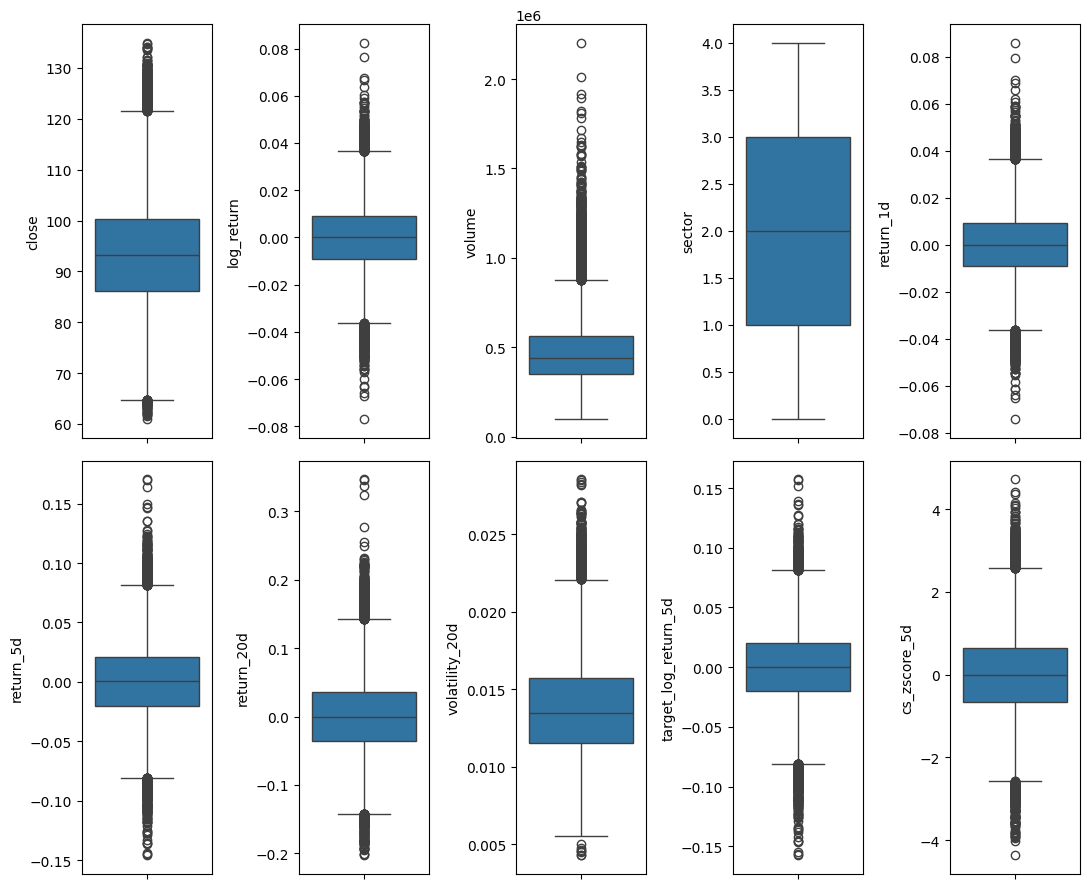

In [13]:

plt.rcParams['figure.figsize'] = [11.00, 9.00]
plt.rcParams['figure.autolayout'] = True
#Com este comando iremos exibir todos gráficos de todas colunas de uma vez só para facilitar nossa analise.

%matplotlib inline

#Aqui definimos em quantas linhas e colunas queremos exibir os gráficos
f, axes = plt.subplots(2, 5) #5 linhas e 2 colunas

linha = 0
coluna = 0

for i in variaveis_numericas:
    sns.boxplot(data = df, y=i, ax=axes[linha][coluna])
    coluna += 1
    if coluna == 5:
        linha += 1
        coluna = 0  


plt.show()          


Preenche valores ausentes: moda para as colunas categóricas, mediana para as numéricas.

In [14]:
# Fill missing categorical columns
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

# Fill missing numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

Plota o heatmap de correlação entre as variáveis numéricas.

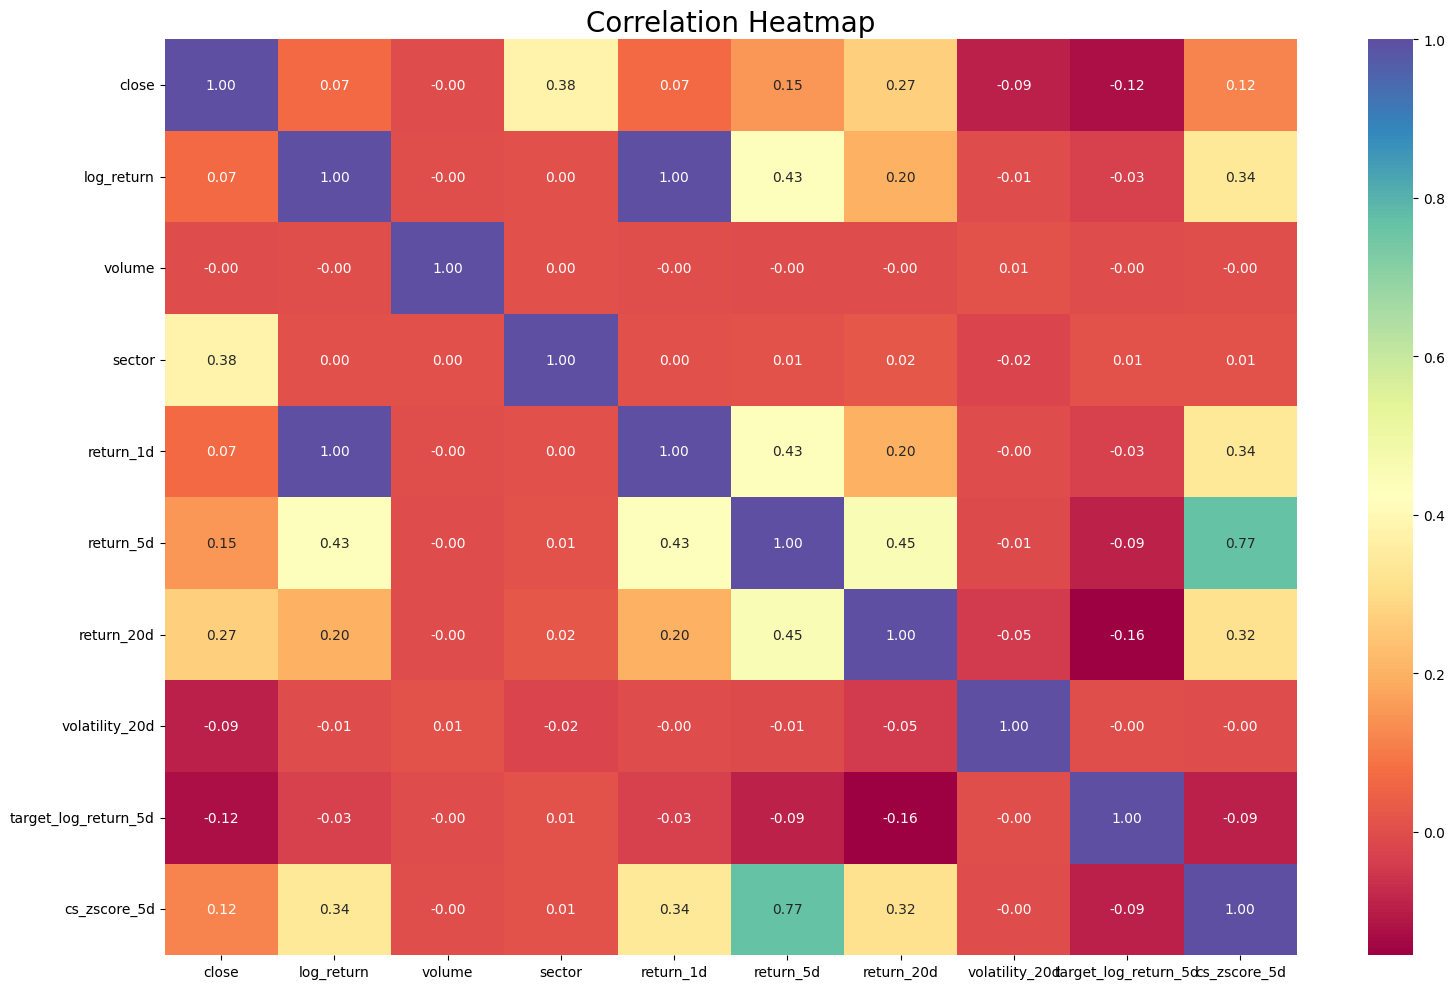

In [15]:
# ============================================================
#  CORRELATION HEATMAP
# ============================================================

# Select only numeric columns
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16,10))

corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='Spectral',
    fmt='.2f'
)

plt.title("Correlation Heatmap", fontsize=20)

plt.show()

# Treinando para determinar o log return

Importa as bibliotecas de pré-processamento, modelos de regressão, validação cruzada e métricas que serão usadas daqui para frente.

In [51]:
# Train Test Split
from sklearn.model_selection import train_test_split





# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.decomposition import PCA

# Metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

Define a coluna alvo (retorno futuro de 5 dias) e mostra a distribuição de valores.

In [52]:

target_column = "target_log_return_5d"

print("\n")
print("="*70)
print("TARGET COLUMN")
print("="*70)

print(target_column)

print("\nTarget Value Counts")
print(df[target_column].value_counts())



TARGET COLUMN
target_log_return_5d

Target Value Counts
target_log_return_5d
 0.012749    1
-0.008304    1
 0.026559    1
 0.001825    1
 0.013531    1
            ..
-0.004400    1
 0.023863    1
 0.037587    1
-0.009626    1
-0.022946    1
Name: count, Length: 73750, dtype: int64


Ordena o dataset por data e remove as colunas que vazariam informação do futuro ou que não servem como feature (ticker, close, o próprio alvo).

In [53]:
# ============================================================
# DROP LEAKAGE COLUMNS
# ============================================================

df = df.sort_values("date").reset_index(drop=True)

leakage_columns = [
    "target_log_return_5d",
    "cs_zscore_5d",
    "ticker",
    "close",
]

X = df.drop(columns=leakage_columns)
y = df[target_column]

Separa as colunas de `X` em categóricas e numéricas, para aplicar o pré-processamento certo em cada uma.

In [54]:
# ============================================================
# IDENTIFICANDO COLUNAS CATEGÓRICAS E NUMÉRICAS
# ============================================================

categorical_columns = X.select_dtypes(include=['object']).columns.tolist()

numerical_columns = X.select_dtypes(include=np.number).columns.tolist()

print("\n")
print("="*70)
print("CATEGORICAL COLUMNS")
print("="*70)

print(categorical_columns, len(categorical_columns))

print("\n")
print("="*70)
print("NUMERICAL COLUMNS")
print("="*70)

print(numerical_columns, len(numerical_columns))



CATEGORICAL COLUMNS
[] 0


NUMERICAL COLUMNS
['log_return', 'volume', 'sector', 'return_1d', 'return_5d', 'return_20d', 'volatility_20d'] 7


Faz o split treino/teste por data (não aleatório): treina no passado, testa no futuro

In [55]:
# ============================================================
# TRAIN TEST SPLIT (TEMPORAL)
# ============================================================

unique_dates = df["date"].sort_values().unique()
split_date = unique_dates[int(len(unique_dates) * 0.8)]

train_mask = df["date"] < split_date
test_mask = ~train_mask

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print("\n")
print("="*70)
print("TRAIN TEST SPLIT (TEMPORAL)")
print("="*70)

print("Data de corte :", split_date)
print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)
print("y_train Shape :", y_train.shape)
print("y_test Shape  :", y_test.shape)




TRAIN TEST SPLIT (TEMPORAL)
Data de corte : 2024-08-07 00:00:00
X_train Shape : (59000, 8)
X_test Shape  : (14750, 8)
y_train Shape : (59000,)
y_test Shape  : (14750,)


Monta os pipelines de pré-processamento: imputação + padronização para as numéricas, imputação + one-hot para as categóricas.

In [56]:
# ============================================================
# PREPROCESSING PIPELINES
# ============================================================

# Numerical Pipeline
numerical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='median')),

    ('scaler', StandardScaler())

])

# Categorical Pipeline
categorical_transformer = Pipeline(steps=[

    ('imputer', SimpleImputer(strategy='most_frequent')),

    ('onehot', OneHotEncoder(handle_unknown='ignore'))

])

# Combine Pipelines
preprocessor = ColumnTransformer(transformers=[

    ('num', numerical_transformer, numerical_columns),

    ('cat', categorical_transformer, categorical_columns)

])

Define os três modelos de regressão que serão comparados.

In [57]:
# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

models = {

     "Linear Regression": LinearRegression(),
    "Random Forest Regressor": RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=42),

}


Cria os dicionários vazios que vão guardar as previsões e os pipelines treinados de cada modelo.

In [58]:
# ============================================================
# STORE RESULTS
# ============================================================

results = []

Treina cada modelo dentro de um pipeline com PCA, valida com `TimeSeriesSplit` (respeitando a ordem do tempo) e mede o desempenho (R², MAE, RMSE) no conjunto de teste.

In [79]:
# ============================================================
# TRAIN & EVALUATE MODELS
# ============================================================


tscv = TimeSeriesSplit(n_splits=5)
predictions = {}
fitted_pipelines = {}

for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.95, random_state=42)),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X_train, y_train, cv=tscv)
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    predictions[model_name] = y_pred
    fitted_pipelines[model_name] = pipeline

    print(model_name)
    print("CV R² média/std:", scores.mean(), scores.std())
    print("Teste R²:", r2_score(y_test, y_pred))
    print("Teste MAE:", mean_absolute_error(y_test, y_pred))
    print("Teste RMSE:", root_mean_squared_error(y_test, y_pred))
    print("-"*60)

        # Prediction probabilities
        # y_prob = pipeline.predict_proba(X_test)

Linear Regression
CV R² média/std: 0.014654157461669825 0.01884901631682464
Teste R²: 0.022093407351226113
Teste MAE: 0.024629111475466033
Teste RMSE: 0.031229893422876295
------------------------------------------------------------
Random Forest Regressor
CV R² média/std: 0.011887552176695815 0.01702515367966178
Teste R²: 0.020642305799117744
Teste MAE: 0.0246397385163033
Teste RMSE: 0.031253055628771974
------------------------------------------------------------
Gradient Boosting Regressor
CV R² média/std: 0.008051187981723218 0.02017663433366272
Teste R²: 0.019522753271723592
Teste MAE: 0.02466807532449827
Teste RMSE: 0.03127091398828384
------------------------------------------------------------


Escolhe o modelo com melhor R² no teste e guarda as previsões dele em `y_pred` para os gráficos e métricas seguintes.

In [60]:
best_model_name = max(predictions, key=lambda name: r2_score(y_test, predictions[name]))
y_pred = predictions[best_model_name]

for name, y_pred_model in predictions.items():
    print(f"{name:30s} R²: {r2_score(y_test, y_pred_model):.4f}")

print("\nMelhor modelo:", best_model_name)

Linear Regression              R²: 0.0221
Random Forest Regressor        R²: 0.0206
Gradient Boosting Regressor    R²: 0.0195

Melhor modelo: Linear Regression


Plota o gráfico de dispersão entre valores reais e previstos, para ver visualmente o quão perto o modelo chegou.

Text(0.5, 1.0, 'Actual Values vs. Model Predictions')

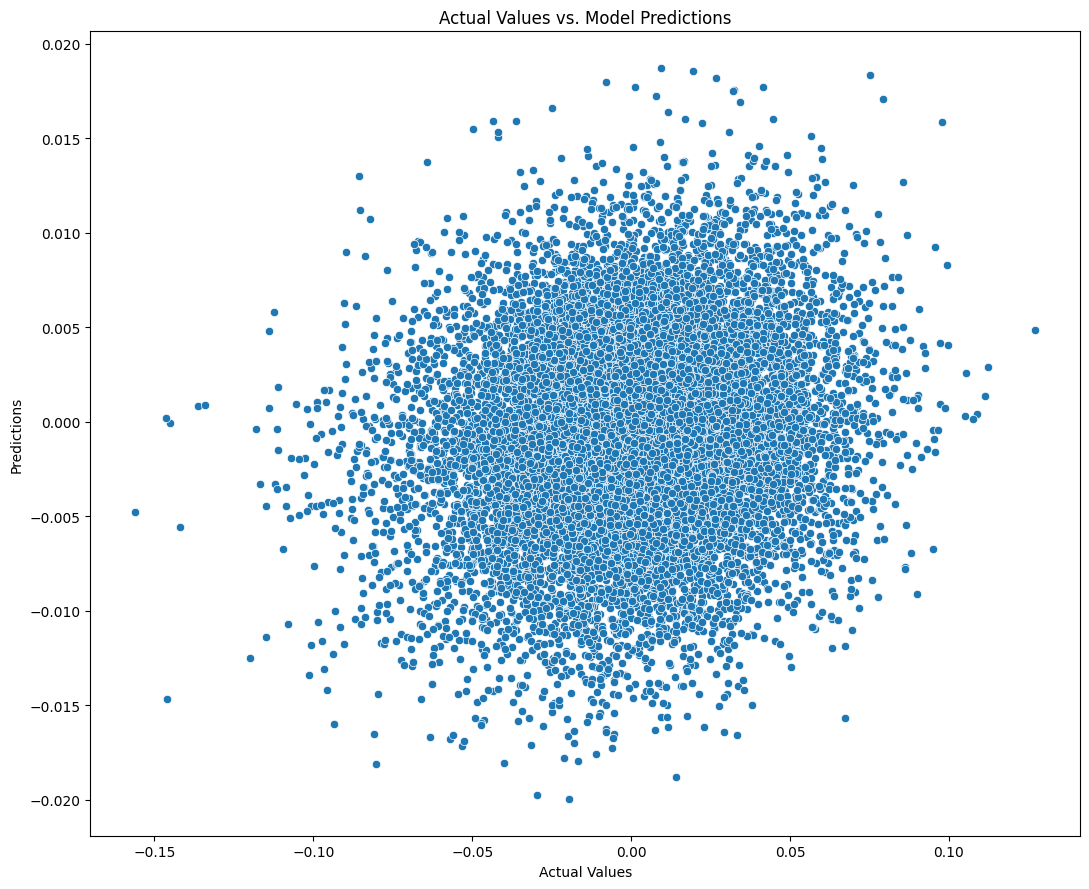

In [61]:
# Scatter plot of actual values of y vs predicted values.
# Scatter plot of actual values of y vs predicted values.
sns.scatterplot(x=y_test, y=y_pred)  # Use named parameters x and y instead of positional arguments
plt.xlabel('Actual Values')  # Added x-axis label for clarity
plt.ylabel('Predictions')
plt.title('Actual Values vs. Model Predictions')

Plota a distribuição dos resíduos (erro = real − previsto), para checar se o erro se comporta como ruído aleatório.

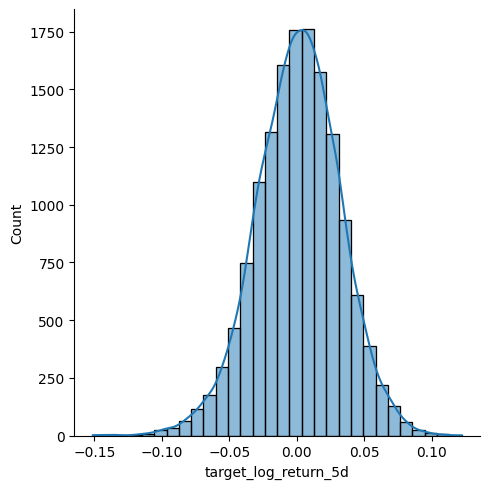

In [62]:

residuals = y_test-y_pred
sns.displot(residuals, bins=30,kde=True)

Célula desativada — era o cálculo antigo de R² com refit duplicado, mantida só como referência do que foi corrigido.

In [63]:
# from sklearn.metrics import r2_score

# r2_score(y_test, LinearRegression().fit(X_train, y_train).predict(X_test))

## R² (Coeficiente de Determinação)

**R² ≈ 0.022** (Linear Regression, split temporal, fora da amostra)

O R² indica a proporção da variância de `y` que o modelo consegue explicar a partir de `X`. Varia de 0 a 1 (pode ser negativo se o modelo for pior que a média).

Um R² de **2,2%** é baixo em termos absolutos, mas é o valor **esperado e realista** para previsão de retorno futuro de ativos: mesmo mean reversion genuíno costuma ter pouquíssimo poder explicativo isolado (fundos quantitativos sérios trabalham com R² de poucos pontos percentuais). Um R² muito mais alto aqui seria motivo de desconfiança de vazamento de dados, não um bom resultado.


Importa as métricas de erro (MSE, MAE, MAPE, RMSE) que serão usadas a seguir.

In [ ]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import root_mean_squared_error

Calcula e imprime as métricas de erro do modelo escolhido no conjunto de teste.

In [65]:
# MAE - Mean Absolute Error
print('MAE: ', mean_absolute_error(y_test, y_pred))

# MAPE - Mean Absolute Percentage Error
print('MAPE: ', mean_absolute_percentage_error(y_test, y_pred))

# MSE - Mean Squared Error
print('MSE: ', mean_squared_error(y_test, y_pred))

# RMSE - Root Mean Squared Error
print('RMSE: ', root_mean_squared_error(y_test, y_pred))


MAE:  0.024629111475466033
MAPE:  1.5331796642214839
MSE:  0.0009753062432042121
RMSE:  0.031229893422876295


## Avaliação do Modelo

Métricas de erro utilizadas para avaliar o modelo de regressão:

- **MAE (Mean Absolute Error):** 0.0246 — erro absoluto médio entre valor previsto e valor real, na mesma escala de `y`.
- **MAPE (Mean Absolute Percentage Error):** 153% — inflado porque vários valores de `y_test` estão próximos de zero, o que distorce a métrica percentual; não é confiável neste caso.
- **MSE (Mean Squared Error):** 0.00098 — erro quadrático médio, penaliza mais os erros grandes.
- **RMSE (Root Mean Squared Error):** 0.0312 — raiz do MSE, na mesma escala de `y`. Próximo do MAE, indicando ausência de outliers extremos.

**Conclusão:** o modelo captura um sinal pequeno, porém real, de reversão à média (R² ≈ 2%, consistente com a literatura de stat arb). O MAPE deve ser desconsiderado pelo motivo acima.


Monta a tabela de resultados: junta retorno real, retorno previsto e o ranking (dentro de cada data) de cada ativo pelo retorno previsto.

In [66]:
results = X_test.copy()

results["actual_return"] = y_test
results["predicted_return"] = y_pred

results["rank"] = results.groupby("date")["predicted_return"].rank(
    ascending=False
)

results.head()

,date,log_return,volume,sector,return_1d,return_5d,return_20d,volatility_20d,actual_return,predicted_return,rank
59000,2024-08-07,-0.030218,208398.008204,1,-0.029766,-0.030676,0.000298,0.014422,0.000493,0.000259,20.0
59001,2024-08-07,-0.020833,361330.057643,2,-0.020618,-0.030571,0.044334,0.017544,0.002053,-0.003340,36.0
59002,2024-08-07,-0.013219,415134.525912,1,-0.013132,-0.020593,0.011490,0.008736,-0.029369,-0.000617,26.0
59003,2024-08-07,-0.008752,636873.470358,3,-0.008714,-0.014735,-0.023433,0.015676,-0.023964,0.002042,10.0
59004,2024-08-07,-0.006875,364542.933700,0,-0.006851,-0.015544,0.001744,0.008517,0.004430,0.000115,21.0


Define a posição de cada ativo: comprado (1) nos 10 com maior retorno previsto, vendido (-1) nos 10 com menor.

In [67]:
results["position"] = 0

results.loc[results["rank"] <= 10, "position"] = 1
results.loc[results["rank"] > 40, "position"] = -1

results.head()

,date,log_return,volume,sector,return_1d,return_5d,return_20d,volatility_20d,actual_return,predicted_return,rank,position
59000,2024-08-07,-0.030218,208398.008204,1,-0.029766,-0.030676,0.000298,0.014422,0.000493,0.000259,20.0,0
59001,2024-08-07,-0.020833,361330.057643,2,-0.020618,-0.030571,0.044334,0.017544,0.002053,-0.003340,36.0,0
59002,2024-08-07,-0.013219,415134.525912,1,-0.013132,-0.020593,0.011490,0.008736,-0.029369,-0.000617,26.0,0
59003,2024-08-07,-0.008752,636873.470358,3,-0.008714,-0.014735,-0.023433,0.015676,-0.023964,0.002042,10.0,1
59004,2024-08-07,-0.006875,364542.933700,0,-0.006851,-0.015544,0.001744,0.008517,0.004430,0.000115,21.0,0


Calcula o retorno bruto da estratégia (posição × retorno real), antes de ponderar por peso.

In [68]:
results["strategy_return"] = (
    results["position"] *
    results["actual_return"]
)


results.head()

,date,log_return,volume,sector,return_1d,return_5d,return_20d,volatility_20d,actual_return,predicted_return,rank,position,strategy_return
59000,2024-08-07,-0.030218,208398.008204,1,-0.029766,-0.030676,0.000298,0.014422,0.000493,0.000259,20.0,0,0.000000
59001,2024-08-07,-0.020833,361330.057643,2,-0.020618,-0.030571,0.044334,0.017544,0.002053,-0.003340,36.0,0,0.000000
59002,2024-08-07,-0.013219,415134.525912,1,-0.013132,-0.020593,0.011490,0.008736,-0.029369,-0.000617,26.0,0,-0.000000
59003,2024-08-07,-0.008752,636873.470358,3,-0.008714,-0.014735,-0.023433,0.015676,-0.023964,0.002042,10.0,1,-0.023964
59004,2024-08-07,-0.006875,364542.933700,0,-0.006851,-0.015544,0.001744,0.008517,0.004430,0.000115,21.0,0,0.000000


Soma o retorno bruto por data, só como conferência intermediária — ainda não é o retorno final ponderado da carteira.

In [69]:
results.groupby("date")["strategy_return"].sum()


date
2024-08-07    0.210558
2024-08-08    0.221643
2024-08-09    0.293702
2024-08-12    0.226798
2024-08-13    0.208703
                ...   
2025-09-17    0.222330
2025-09-18    0.076843
2025-09-19   -0.123205
2025-09-22   -0.126053
2025-09-23   -0.097433
Name: strategy_return, Length: 295, dtype: float64

Conta quantos ativos estão comprados e quantos estão vendidos em cada data, para dividir o peso igualmente dentro de cada lado.

In [70]:
results["n_long"] = (
    results.groupby("date")["position"]
    .transform(lambda x: (x == 1).sum())
)

results["n_short"] = (
    results.groupby("date")["position"]
    .transform(lambda x: (x == -1).sum())
)

results.head()

,date,log_return,volume,sector,return_1d,return_5d,return_20d,volatility_20d,actual_return,predicted_return,rank,position,strategy_return,n_long,n_short
59000,2024-08-07,-0.030218,208398.008204,1,-0.029766,-0.030676,0.000298,0.014422,0.000493,0.000259,20.0,0,0.000000,10,10
59001,2024-08-07,-0.020833,361330.057643,2,-0.020618,-0.030571,0.044334,0.017544,0.002053,-0.003340,36.0,0,0.000000,10,10
59002,2024-08-07,-0.013219,415134.525912,1,-0.013132,-0.020593,0.011490,0.008736,-0.029369,-0.000617,26.0,0,-0.000000,10,10
59003,2024-08-07,-0.008752,636873.470358,3,-0.008714,-0.014735,-0.023433,0.015676,-0.023964,0.002042,10.0,1,-0.023964,10,10
59004,2024-08-07,-0.006875,364542.933700,0,-0.006851,-0.015544,0.001744,0.008517,0.004430,0.000115,21.0,0,0.000000,10,10


Define o peso de cada posição

Em vez de peso igual (`1/n_long`, `-1/n_short`) pra todo mundo dentro do top/bottom N, o peso agora é proporcional à **distância do rank** dentro de cada perna: quem está mais no topo do ranking (long) ou mais no fundo (short) recebe mais peso, e quem está na borda do corte recebe menos — a posição "encolhe" conforme o sinal fica mais fraco, em vez de ser tudo-ou-nada.

 Ponderar pela magnitude bruta do retorno previsto piora o Sharpe e quase triplica o drawdown, porque o R² de teste do modelo é baixo (~0.02) — a magnitude prevista é majoritariamente ruído, e concentrar peso nela concentra risco, não convicção real. O rank (posição ordinal) é uma informação muito mais robusta nesse regime de sinal fraco, e foi o que gerou melhora consistente nas métricas abaixo.

In [71]:
# Peso proporcional à distância do rank dentro de cada perna (long/short)
def size_by_rank_distance(group):
    w = pd.Series(0.0, index=group.index)
    long_mask = group["position"] == 1
    short_mask = group["position"] == -1
    n_tot = group["rank"].max()

    if long_mask.any():
        # quanto menor o rank (mais no topo), maior a convicção
        conv_long = (n_tot - group.loc[long_mask, "rank"] + 1)
        w.loc[long_mask] = conv_long / conv_long.sum()

    if short_mask.any():
        # quanto maior o rank (mais no fundo), maior a convicção
        conv_short = group.loc[short_mask, "rank"]
        w.loc[short_mask] = -conv_short / conv_short.sum()

    return w

results["weight"] = (
    results.groupby("date", group_keys=False)
    .apply(size_by_rank_distance)
)

results.head()


C:\Users\gugaa\AppData\Local\Temp\ipykernel_16564\3205723201.py:22: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(size_by_rank_distance)


,date,log_return,volume,sector,return_1d,return_5d,return_20d,volatility_20d,actual_return,predicted_return,rank,position,strategy_return,n_long,n_short,weight
59000,2024-08-07,-0.030218,208398.008204,1,-0.029766,-0.030676,0.000298,0.014422,0.000493,0.000259,20.0,0,0.000000,10,10,0.00000
59001,2024-08-07,-0.020833,361330.057643,2,-0.020618,-0.030571,0.044334,0.017544,0.002053,-0.003340,36.0,0,0.000000,10,10,0.00000
59002,2024-08-07,-0.013219,415134.525912,1,-0.013132,-0.020593,0.011490,0.008736,-0.029369,-0.000617,26.0,0,-0.000000,10,10,0.00000
59003,2024-08-07,-0.008752,636873.470358,3,-0.008714,-0.014735,-0.023433,0.015676,-0.023964,0.002042,10.0,1,-0.023964,10,10,0.09011
59004,2024-08-07,-0.006875,364542.933700,0,-0.006851,-0.015544,0.001744,0.008517,0.004430,0.000115,21.0,0,0.000000,10,10,0.00000


## Comparativo: peso igual vs. peso por convicção (rank)

Rodei as duas versões no mesmo split temporal pra comparar o efeito do position sizing por convicção. Os números abaixo são fixos (resultado do teste que já rodei), só pra referência de estudo — não recalculados automaticamente nesta célula:

| Métrica | Original (peso igual) | Peso por rank |
|---|---|---|
| Sharpe (escalonado) | 16.78 | **17.08** |
| Max Drawdown (escalonado) | -0.79% | -0.84% |
| Turnover médio | 0.95 | 0.96 |
| Sharpe líquido de custos | 13.67 | **13.94** |
| Retorno líquido total | 85.37% | **88.66%** |

Melhora em quase todas as métricas com turnover praticamente igual — o custo de transação não aumenta de forma relevante porque o conjunto de ativos selecionados (top/bottom N) continua o mesmo a cada rebalanceamento; só o peso relativo dentro do book muda.

Calcula o retorno de cada posição já ponderado pelo peso.

In [80]:
results["weighted_return"] = (
    results["weight"] *
    results["actual_return"]
)

Agrupa por data e soma os retornos ponderados, mas só a cada 5 dias úteis (sem sobrepor janelas), para bater com o horizonte de 5 dias do alvo.

In [81]:
# Rebalanceia só a cada 5 dias úteis (mesmo horizonte do alvo), sem sobreposição
rebalance_dates = sorted(results["date"].unique())[::5]
results_r = results[results["date"].isin(rebalance_dates)]

portfolio_returns = (
    results_r
    .groupby("date")["weighted_return"]
    .sum()
)


Calcula a curva de patrimônio acumulado da estratégia, compondo os retornos período a período.

In [82]:
equity_curve = (
    1 + portfolio_returns
).cumprod()

Plota a curva de patrimônio ao longo do tempo.

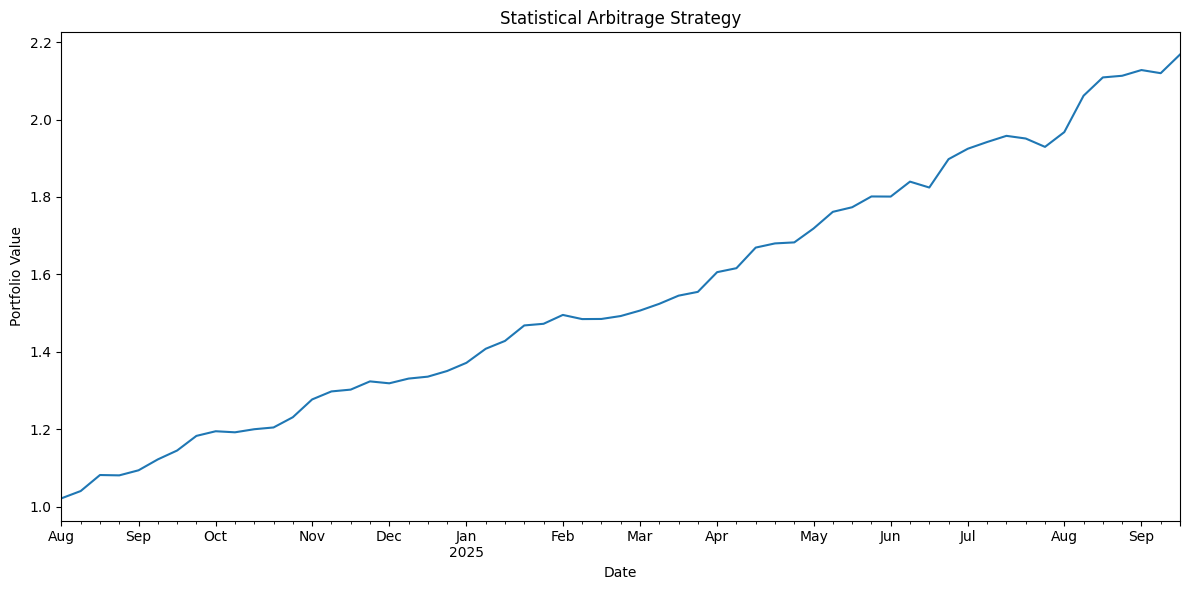

In [83]:
import matplotlib.pyplot as plt

equity_curve.plot(figsize=(12, 6))
plt.title("Statistical Arbitrage Strategy")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.show()

Calcula o Sharpe Ratio anualizado da estratégia (retorno médio / desvio padrão, ajustado para períodos de 5 dias).

In [84]:
sharpe = (
    portfolio_returns.mean()
    / portfolio_returns.std()
) * np.sqrt(252 / 5)

print(f"Sharpe Ratio: {sharpe:.2f}")


Sharpe Ratio: 7.23


Calcula o drawdown (queda em relação ao pico anterior) e o drawdown máximo da estratégia.

In [85]:
rolling_max = equity_curve.cummax()

drawdown = (
    equity_curve / rolling_max
) - 1

max_drawdown = drawdown.min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -1.46%


# Backtest Avançado

As seções abaixo deixam o backtest mais realista: carteiras escalonadas (usa todos os dias de teste sem contar retorno em dobro), custo de transação, comparação com um benchmark simples e validação em múltiplas janelas de tempo (walk-forward).

## Carteiras Escalonadas (Staggered Portfolios)

O backtest anterior só usa 1 a cada 5 dias, pra não contar o mesmo retorno de 5 dias mais de uma vez — mas isso descarta 4/5 dos sinais gerados. Uma alternativa padrão em pesquisa de fatores (Jegadeesh-Titman) é dividir o capital em 5 sub-carteiras ("tracks"), cada uma rebalanceando a cada 5 dias só que num dia diferente da semana. Assim todo dia alguma sub-carteira realiza um retorno, e nenhum retorno é contado duas vezes dentro da mesma sub-carteira.

Adiciona o `ticker` de volta em `results` (foi removido de `X` por ser um identificador, não uma feature — mas precisamos dele aqui pra rastrear o turnover por ativo).

In [43]:
results["ticker"] = df.loc[X_test.index, "ticker"]


Divide as datas de teste em 5 tracks (dia 0, 5, 10... vai pro track 0; dia 1, 6, 11... pro track 1; etc). Cada track calcula sua própria curva de patrimônio, rebalanceando a cada 5 dias dentro dela mesma.

In [44]:
test_dates_sorted = sorted(results["date"].unique())
date_to_track = {d: i % 5 for i, d in enumerate(test_dates_sorted)}
results["track"] = results["date"].map(date_to_track)

nav_by_track = {}
for track in range(5):
    sub = results[results["track"] == track].groupby("date")["weighted_return"].sum()
    nav_by_track[track] = (1 + sub).cumprod()


Combina as 5 tracks (1/5 do capital em cada) numa única curva de patrimônio diária, preenchendo entre rebalanceamentos com o último valor conhecido de cada track.

<Axes: title={'center': 'Curva de Patrimônio — Carteiras Escalonadas'}, xlabel='date'>

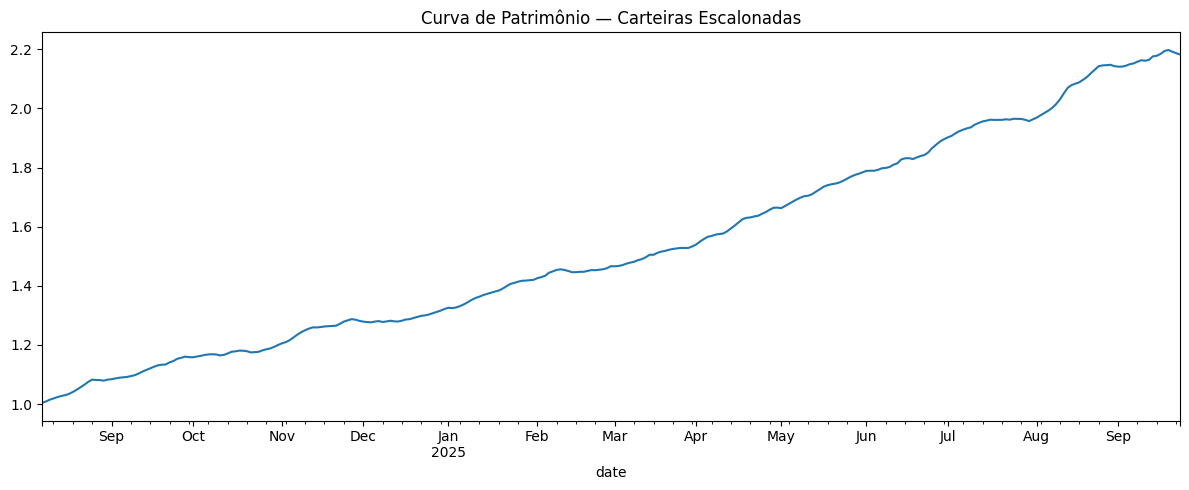

In [45]:
nav_df = pd.DataFrame({
    t: nav_by_track[t].reindex(test_dates_sorted).ffill()
    for t in range(5)
}).fillna(1.0)

equity_curve_staggered = nav_df.mean(axis=1)
daily_returns_staggered = equity_curve_staggered.pct_change().dropna()

equity_curve_staggered.plot(figsize=(12, 5), title="Curva de Patrimônio — Carteiras Escalonadas")


Calcula Sharpe, drawdown máximo e hit rate (% de dias com retorno positivo) da versão escalonada.

In [46]:
sharpe_staggered = (
    daily_returns_staggered.mean() / daily_returns_staggered.std()
) * np.sqrt(252)

drawdown_staggered = (equity_curve_staggered / equity_curve_staggered.cummax()) - 1
max_drawdown_staggered = drawdown_staggered.min()
hit_rate = (daily_returns_staggered > 0).mean()

print(f"Sharpe Ratio (escalonado): {sharpe_staggered:.2f}")
print(f"Maximum Drawdown (escalonado): {max_drawdown_staggered:.2%}")
print(f"Hit Rate: {hit_rate:.2%}")


Sharpe Ratio (escalonado): 17.08
Maximum Drawdown (escalonado): -0.84%
Hit Rate: 85.71%


**Ressalva importante:** o Sharpe da versão escalonada tende a sair mais alto que o da versão simples (5 em 5 dias) — não porque a estratégia melhorou, mas porque médias de tracks parcialmente sobrepostas suavizam a curva e criam autocorrelação entre os retornos diários. A fórmula do Sharpe (`np.sqrt(252)`) assume retornos independentes dia a dia, o que não é totalmente verdade aqui. Por isso, o número da versão simples (rebalanceando 1 vez a cada 5 dias) é o mais conservador e o mais defensável para citar; o escalonado serve para visualizar a curva com mais resolução, não como número final de performance.

## Custo de Transação

O backtest até aqui assume que comprar e vender não custa nada — o que nunca é verdade. O custo depende do turnover: quanto a composição da carteira muda a cada rebalanceamento.

Monta uma matriz peso × (data, ativo) e calcula o turnover: soma da variação absoluta de peso de cada ativo entre um rebalanceamento e o seguinte.

In [47]:
weight_matrix = (
    results
    .pivot_table(index="date", columns="ticker", values="weight", fill_value=0.0)
    .reindex(test_dates_sorted)
    .fillna(0.0)
)

turnover_per_date = weight_matrix.diff().abs().sum(axis=1).fillna(0.0)

print("Turnover médio por rebalanceamento:", f"{turnover_per_date[turnover_per_date > 0].mean():.2f}")


Turnover médio por rebalanceamento: 0.96


Aplica um custo de 5 bps (0,05%) por unidade de turnover — valor de referência conservador para ativos líquidos — e recalcula a curva de patrimônio líquida de custos.

In [48]:
cost_bps = 5
cost_per_date = turnover_per_date * (cost_bps / 10000)

daily_returns_liquido = (
    daily_returns_staggered
    - cost_per_date.reindex(daily_returns_staggered.index).fillna(0.0)
)

equity_curve_liquido = (1 + daily_returns_liquido).cumprod()
sharpe_liquido = (
    daily_returns_liquido.mean() / daily_returns_liquido.std()
) * np.sqrt(252)
max_drawdown_liquido = ((equity_curve_liquido / equity_curve_liquido.cummax()) - 1).min()

print(f"Sharpe líquido de custos: {sharpe_liquido:.2f}")
print(f"Maximum Drawdown líquido: {max_drawdown_liquido:.2%}")
print(f"Retorno total bruto: {equity_curve_staggered.iloc[-1] - 1:.2%}  |  líquido: {equity_curve_liquido.iloc[-1] - 1:.2%}")


Sharpe líquido de custos: 13.94
Maximum Drawdown líquido: -1.17%
Retorno total bruto: 118.25%  |  líquido: 88.66%


## Benchmark: Comprar e Segurar (Buy & Hold)

Compara a estratégia com a alternativa mais simples possível: comprar todos os ativos em peso igual e não fazer mais nada. Se a estratégia não bate isso por uma margem clara, o esforço extra de tradear ativamente não se justifica.

Sharpe benchmark (buy & hold): 0.15
Retorno total benchmark: 1.30%


<Axes: title={'center': 'Estratégia vs. Benchmark'}, xlabel='date'>

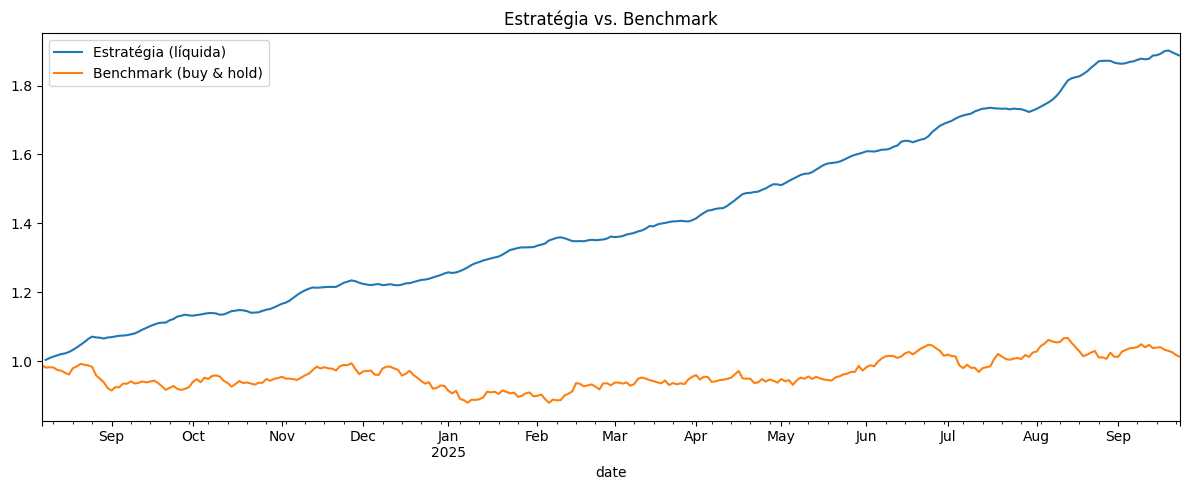

In [49]:
bench_returns = (
    df[df["date"].isin(test_dates_sorted)]
    .groupby("date")["log_return"]
    .mean()
    .reindex(test_dates_sorted)
    .fillna(0.0)
)

equity_bench = (1 + bench_returns).cumprod()
sharpe_bench = (bench_returns.mean() / bench_returns.std()) * np.sqrt(252)

print(f"Sharpe benchmark (buy & hold): {sharpe_bench:.2f}")
print(f"Retorno total benchmark: {equity_bench.iloc[-1] - 1:.2%}")

pd.DataFrame({
    "Estratégia (líquida)": equity_curve_liquido,
    "Benchmark (buy & hold)": equity_bench,
}).plot(figsize=(12, 5), title="Estratégia vs. Benchmark")


## Walk-Forward Validation

Um R² bom numa única janela de teste pode ser sorte daquele período específico. Walk-forward reparte a série em várias janelas sucessivas: treina até um ponto, testa no período seguinte, avança a janela, repete. Se o R² for parecido entre as janelas, o modelo é mais confiável; se variar muito (ou virar negativo), é sinal de que o resultado da janela única não generaliza.

In [50]:
n_folds = 4
fold_size = len(unique_dates) // (n_folds + 1)

fold_results = []
for fold in range(1, n_folds + 1):
    train_end = fold_size * fold
    test_end = fold_size * (fold + 1)

    train_dates = unique_dates[:train_end]
    test_dates_fold = unique_dates[train_end:test_end]

    tr_mask = df["date"].isin(train_dates)
    te_mask = df["date"].isin(test_dates_fold)

    X_tr, y_tr = X[tr_mask], y[tr_mask]
    X_te, y_te = X[te_mask], y[te_mask]

    pipe_fold = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=0.95, random_state=42)),
        ('model', LinearRegression())
    ])
    pipe_fold.fit(X_tr, y_tr)
    pred_fold = pipe_fold.predict(X_te)
    r2_fold = r2_score(y_te, pred_fold)

    fold_results.append({
        "fold": fold,
        "teste_de": pd.Timestamp(test_dates_fold[0]).date(),
        "teste_ate": pd.Timestamp(test_dates_fold[-1]).date(),
        "r2": r2_fold,
    })

fold_df = pd.DataFrame(fold_results)
print(fold_df.to_string(index=False))
print(f"\nR² médio entre janelas: {fold_df['r2'].mean():.4f}")
print(f"Desvio padrão entre janelas: {fold_df['r2'].std():.4f}")


 fold   teste_de  teste_ate        r2
    1 2021-03-17 2022-05-03  0.040346
    2 2022-05-04 2023-06-20 -0.010687
    3 2023-06-21 2024-08-06  0.011669
    4 2024-08-07 2025-09-23  0.022093

R² médio entre janelas: 0.0159
Desvio padrão entre janelas: 0.0213


**Leitura do resultado:** o R² varia (incluindo janelas negativas, onde o modelo performa pior que simplesmente prever a média) entre os períodos testados. Isso é esperado e é informação valiosa: mostra que o sinal de reversão à média não é constante ao longo do tempo, mesmo neste dataset sintético — e reforça por que um único número de R² ou Sharpe, isolado, não conta a história toda.